(range(10, 15), [0, 1, 2, 22, 23, 24, 25], [4, 5, 6, 7, 8, 16, 17, 18, 19, 20])


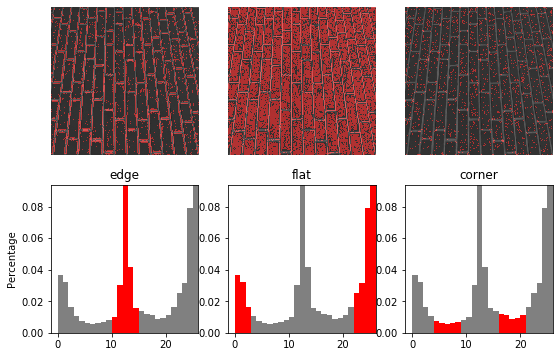

In [13]:
# HOG
import os
import io 
import numpy as np
import matplotlib.pyplot as plt
# from skimage import io, exposure
from skimage.feature import local_binary_pattern #,graycomatrix, graycoprops,
from skimage import data
from skimage.color import label2rgb

img = data.brick()

# settings for LBP
radius = 3
n_points = 8 * radius
METHOD = 'uniform'
# compute LBP features
lbp = local_binary_pattern(img, n_points, radius, METHOD)

def hist(ax, lbp):
    n_bins = int(lbp.max() + 1)
    return ax.hist(lbp.ravel(), density=True, bins=n_bins, range=(0, n_bins), facecolor='0.5')

# plot histograms of LBP of textures
fig, (ax_img, ax_hist) = plt.subplots(nrows=2, ncols=3, figsize=(9, 6))
plt.gray()


titles = ('edge', 'flat', 'corner')
w = width = radius - 1
edge_labels = range(n_points // 2 - w, n_points // 2 + w + 1)
flat_labels = list(range(0, w + 1)) + list(range(n_points - w, n_points + 2))
i_14 = n_points // 4            # 1/4th of the histogram
i_34 = 3 * (n_points // 4)      # 3/4th of the histogram
corner_labels = (list(range(i_14 - w, i_14 + w + 1)) +
                 list(range(i_34 - w, i_34 + w + 1)))

label_sets = (edge_labels, flat_labels, corner_labels)
print(label_sets)

def overlay_labels(image, lbp, labels):
    mask = np.logical_or.reduce([lbp == each for each in labels])
    return label2rgb(mask, image=image, bg_label=0, alpha=0.5)

def highlight_bars(bars, indexes):
    for i in indexes:
        bars[i].set_facecolor('r')

for ax, labels in zip(ax_img, label_sets):
    ax.imshow(overlay_labels(img, lbp, labels))

for ax, labels, name in zip(ax_hist, label_sets, titles):
    counts, _, bars = hist(ax, lbp)
    highlight_bars(bars, labels)
    ax.set_ylim(top=np.max(counts[:-1]))
    ax.set_xlim(right=n_points + 2)
    ax.set_title(name)

ax_hist[0].set_ylabel('Percentage')
for ax in ax_img:
    ax.axis('off')
    

LBP feature
- local representation of texture
- grayscale invariant texture descriptor (Resistance to fluctuations in image gray scale values)
- low-calculation cost

In [ ]:

# # compute some GLCM properties 
# xs = []
# ys = []
# glcm = graycomatrix(img, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)
# xs.append(graycoprops(glcm, 'dissimilarity')[0, 0])
# ys.append(graycoprops(glcm, 'correlation')[0, 0])

# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 8), sharex=True, sharey=True)
# ax1.imshow(img, cmap=plt.cm.gray)
# ax1.set_title('Input image')

# ax2.imshow(xs[0], cmap=plt.cm.gray)
# ax2.set_title('Histogram of Oriented Gradients')

# ax3.imshow(ys[0], cmap=plt.cm.gray)
# ax3.set_title('Histogram of Oriented Gradients (rescaled)')

# plt.show()